In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

In [24]:
x = 8
learning_rate = 0.1

for step in range(20):
    loss = x**2
    gradient = 2*x
    x = x - learning_rate * gradient
    print(step, "x =", round(x, 4), "loss =", round(loss, 4))

0 x = 6.4 loss = 64
1 x = 5.12 loss = 40.96
2 x = 4.096 loss = 26.2144
3 x = 3.2768 loss = 16.7772
4 x = 2.6214 loss = 10.7374
5 x = 2.0972 loss = 6.8719
6 x = 1.6777 loss = 4.398
7 x = 1.3422 loss = 2.8147
8 x = 1.0737 loss = 1.8014
9 x = 0.859 loss = 1.1529
10 x = 0.6872 loss = 0.7379
11 x = 0.5498 loss = 0.4722
12 x = 0.4398 loss = 0.3022
13 x = 0.3518 loss = 0.1934
14 x = 0.2815 loss = 0.1238
15 x = 0.2252 loss = 0.0792
16 x = 0.1801 loss = 0.0507
17 x = 0.1441 loss = 0.0325
18 x = 0.1153 loss = 0.0208
19 x = 0.0922 loss = 0.0133


In [25]:
def gradient_descent(learning_rate, steps, start_x):
    x = start_x
    x_values = [x]
    loss_history = [x**2]

    for step in range(steps):
        loss = x**2
        gradient = 2 * x
        x = x - learning_rate * gradient
        x_values.append(x)
        loss_history.append(x**2)

    return x_values, loss_history

In [26]:
learning_rates = [0.01, 0.1, 0.5, 0.9, 1.1]
steps = 20
start_x = 8

results = []
all_losses = {}

for lr in learning_rates:
    x_vals, losses = gradient_descent(lr, steps, start_x)
    all_losses[lr] = losses
    results.append({
        "learning_rate": lr,
        "initial_loss": losses[0],
        "final_loss": losses[-1],
    })

results_df = pd.DataFrame(results)
results_df

,learning_rate,initial_loss,final_loss
0,0.01,64,28.524826
1,0.10,64,0.008507
2,0.50,64,0.000000
3,0.90,64,0.008507
4,1.10,64,94065.380350


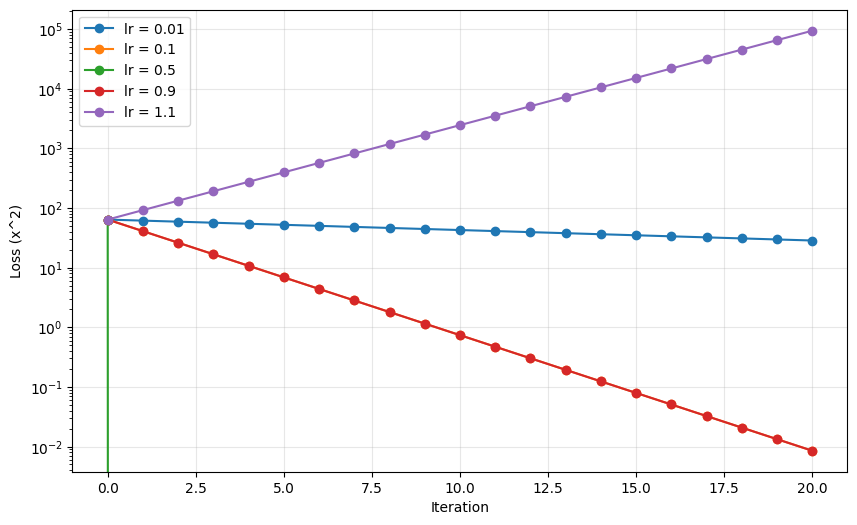

In [27]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(range(len(all_losses[lr])), all_losses[lr], marker='o', label=f"lr = {lr}")

plt.xlabel("Iteration")
plt.ylabel("Loss (x^2)")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", data.target_names)

Features shape: (569, 30)
Target shape: (569,)
Classes: ['malignant' 'benign']


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 455
Test size: 114


In [30]:
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
ll = log_loss(y_test, y_proba)

print("First 5 predictions:", y_pred[:5])
print("First 5 probability rows:\n", y_proba[:5])
print("\nColumn 0 = P(class 0), Column 1 = P(class 1)")
print(f"Accuracy: {acc:.4f}")
print(f"Log Loss: {ll:.4f}")

First 5 predictions: [0 1 0 1 0]
First 5 probability rows:
 [[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]

Column 0 = P(class 0), Column 1 = P(class 1)
Accuracy: 0.9825
Log Loss: 0.0777


In [31]:
prob_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred,
    "probability_class_1": y_proba[:, 1]
})

prob_df.head(10)

top5 = prob_df.sort_values("probability_class_1", ascending=False).head(5)
top5

bottom5 = prob_df.sort_values("probability_class_1", ascending=True).head(5)
bottom5

wrong = prob_df[prob_df["true_label"] != prob_df["predicted_label"]]

print(f"Number of wrong predictions: {len(wrong)}")
if len(wrong) > 0:
    print("\nWrong predictions:")
    print(wrong)
    for idx, row in wrong.iterrows():
        print(f"\nIndex {idx}:")
        print(f"  True label\t: {row['true_label']} ({data.target_names[int(row['true_label'])]})")
        print(f"  Predicted label\t: {row['predicted_label']} ({data.target_names[int(row['predicted_label'])]})")
        print(f"  P(class 1)\t: {row['probability_class_1']:.4f}")
else:
    print("No wrong predictions in this split.")

Number of wrong predictions: 2

Wrong predictions:
    true_label  predicted_label  probability_class_1
16           1                0             0.365862
53           0                1             0.908728

Index 16:
  True label	: 1.0 (benign)
  Predicted label	: 0.0 (malignant)
  P(class 1)	: 0.3659

Index 53:
  True label	: 0.0 (malignant)
  Predicted label	: 1.0 (benign)
  P(class 1)	: 0.9087


In [32]:
random_states = [10, 20, 30, 40, 50]
accuracies = []

for rs in random_states:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=rs, stratify=y
    )
    pipe_rs = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])
    pipe_rs.fit(X_tr, y_tr)
    pred_rs = pipe_rs.predict(X_te)
    acc_rs = accuracy_score(y_te, pred_rs)
    accuracies.append(acc_rs)
    print(f"random_state = {rs} - accuracy = {acc_rs:.4f}")

accuracies = np.array(accuracies)

random_state = 10 - accuracy = 0.9649
random_state = 20 - accuracy = 0.9825
random_state = 30 - accuracy = 0.9825
random_state = 40 - accuracy = 1.0000
random_state = 50 - accuracy = 0.9825


In [15]:
mean_acc = np.mean(accuracies)
print(f"Mean accuracy: {mean_acc:.4f}")

std_acc = np.std(accuracies)
print(f"Standard deviation: {std_acc:.4f}")

n = len(accuracies)
ci_low = mean_acc - 1.96 * std_acc / np.sqrt(n)
ci_high = mean_acc + 1.96 * std_acc / np.sqrt(n)

print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

Mean accuracy: 0.9825
Standard deviation: 0.0111
95% CI: [0.9727, 0.9922]
